<a href="https://colab.research.google.com/github/prasuna-63y/Electric-Motor-Temperature-Prediction/blob/main/Rotor_Temperature_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Numerical computation
import numpy as np

# Data handling
import pandas as pd

# Statistical functions
from scipy import stats

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Model saving
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

df.head()

In [ ]:
df = pd.read_csv('pmsm_temperature_data.csv.csv')
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17.0
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17.0
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17.0
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17.0
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17.0


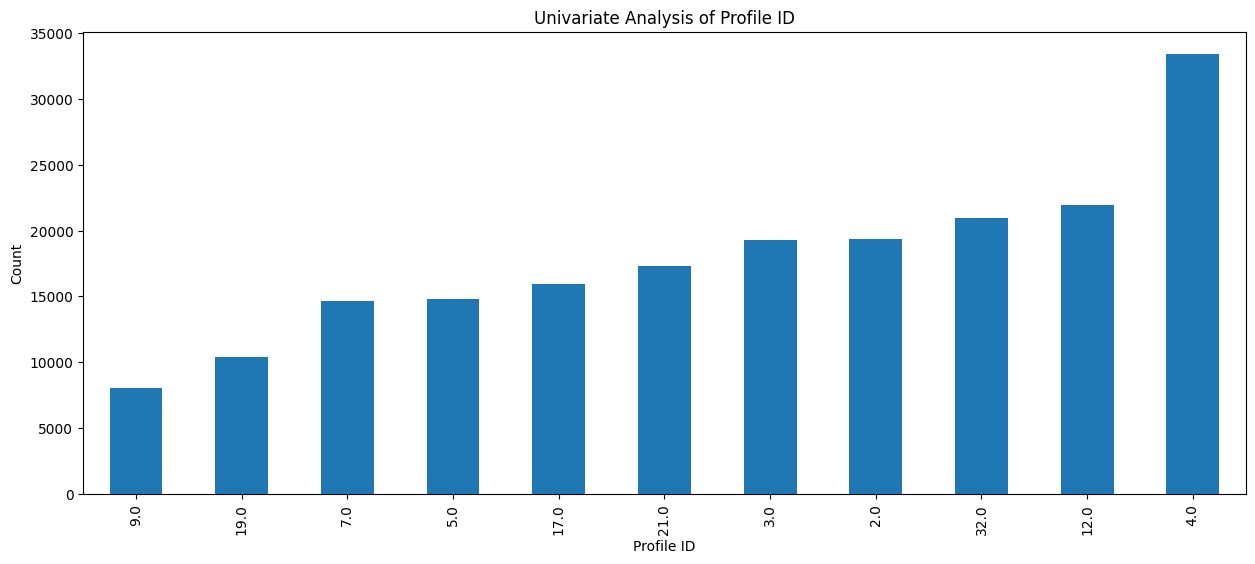

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
df['profile_id'].value_counts().sort_values().plot(kind='bar')
plt.xlabel('Profile ID')
plt.ylabel('Count')
plt.title('Univariate Analysis of Profile ID')
plt.show()


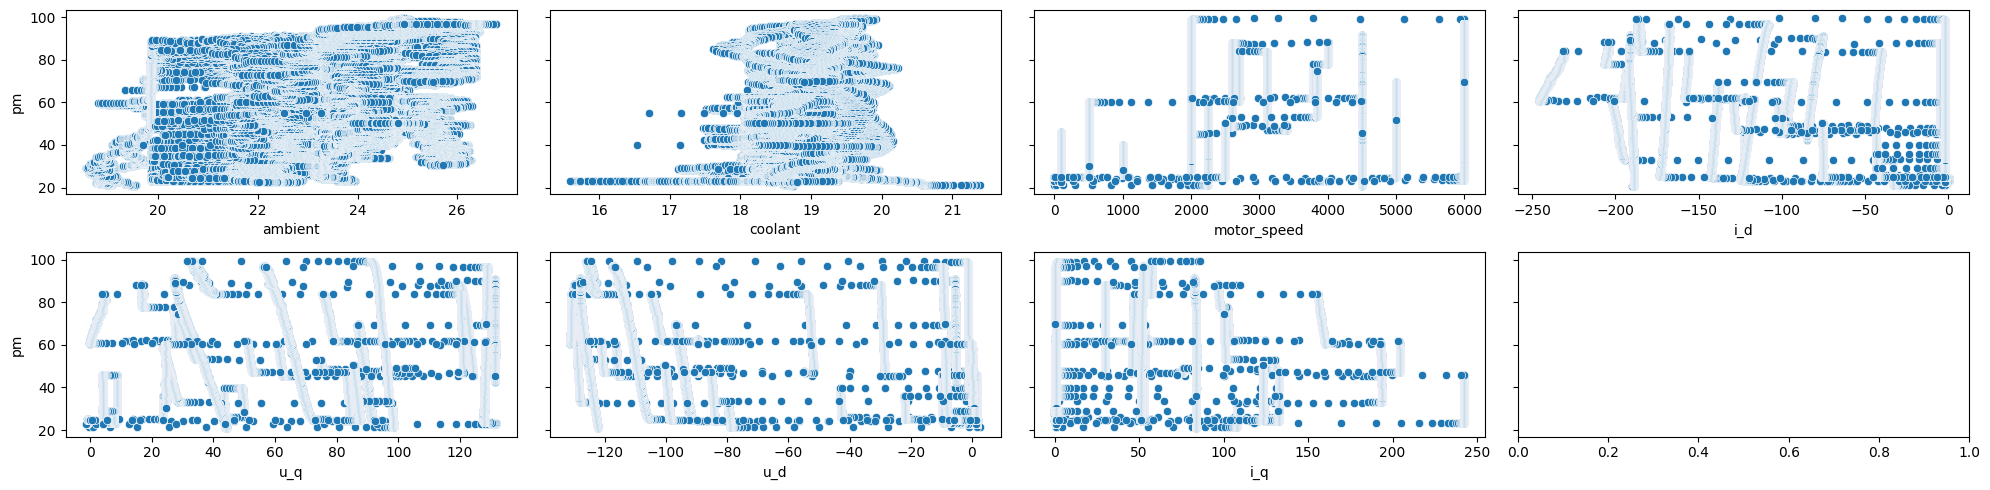

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(20, 5), sharey=True)

sns.scatterplot(x=df['ambient'], y=df['pm'], ax=axes[0][0])
sns.scatterplot(x=df['coolant'], y=df['pm'], ax=axes[0][1])
sns.scatterplot(x=df['motor_speed'], y=df['pm'], ax=axes[0][2])
sns.scatterplot(x=df['i_d'], y=df['pm'], ax=axes[0][3])

sns.scatterplot(x=df['u_q'], y=df['pm'], ax=axes[1][0])
sns.scatterplot(x=df['u_d'], y=df['pm'], ax=axes[1][1])
sns.scatterplot(x=df['i_q'], y=df['pm'], ax=axes[1][2])

plt.tight_layout()
plt.show()


In [ ]:
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196090 entries, 0 to 196089
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   u_q             196090 non-null  float64
 1   coolant         196090 non-null  float64
 2   stator_winding  196090 non-null  float64
 3   u_d             196090 non-null  float64
 4   stator_tooth    196090 non-null  float64
 5   motor_speed     196089 non-null  float64
 6   i_d             196089 non-null  float64
 7   i_q             196089 non-null  float64
 8   pm              196089 non-null  float64
 9   stator_yoke     196089 non-null  float64
 10  ambient         196089 non-null  float64
 11  torque          196089 non-null  float64
 12  profile_id      196089 non-null  float64
dtypes: float64(13)
memory usage: 19.4 MB


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
count,196090.000000,196090.000000,196090.000000,196090.000000,196090.000000,196089.000000,196089.000000,196089.000000,196089.000000,196089.000000,196089.000000,196089.000000,196089.000000
mean,60.822414,18.776077,50.812284,-43.938428,41.764161,2352.628631,-68.102656,67.751070,46.746575,32.661140,23.028252,55.870105,11.453014
std,42.655546,0.422646,27.668914,48.613719,18.870426,1955.956145,63.316969,69.199731,18.641994,11.166884,1.406441,57.870364,9.429309
min,-1.255789,15.594865,18.585815,-131.247696,18.133976,-0.006472,-246.089752,-0.017236,20.856956,18.076689,18.558733,-11.883664,2.000000
25%,23.648676,18.470738,26.201642,-91.730358,26.198995,499.993561,-117.627754,1.097092,32.821232,23.570976,22.169537,-0.010037,4.000000
50%,58.367994,18.723303,43.099821,-9.810401,38.642952,1999.979004,-43.512505,52.757278,43.892223,31.307411,23.161482,48.640797,7.000000
75%,95.642027,19.101536,64.204062,-0.670899,52.571110,4499.954590,-2.001542,132.617203,55.042999,38.576500,23.765171,101.908791,17.000000
max,131.707565,21.393656,131.437012,2.676198,95.034203,6000.015137,0.004419,242.425613,99.396629,64.759232,26.776134,208.290604,32.000000


In [ ]:
df.head()


,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17.0
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17.0
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17.0
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17.0
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17.0


In [ ]:
df = df.drop(['stator_yoke', 'stator_tooth', 'stator_winding', 'torque'], axis=1)


In [ ]:
df.head()


,u_q,coolant,u_d,motor_speed,i_d,i_q,pm,ambient,profile_id
0,-0.450682,18.805172,-0.350055,0.002866,0.004419,0.000328,24.554214,19.850691,17.0
1,-0.325737,18.818571,-0.305803,0.000257,0.000606,-0.000785,24.538078,19.850672,17.0
2,-0.440864,18.828770,-0.372503,0.002355,0.001290,0.000386,24.544693,19.850657,17.0
3,-0.327026,18.835567,-0.316199,0.006105,0.000026,0.002046,24.554018,19.850647,17.0
4,-0.471150,18.857033,-0.332272,0.003133,-0.064317,0.037184,24.565397,19.850639,17.0


In [ ]:
df.isnull().sum()


,0
u_q,0
coolant,0
u_d,0
motor_speed,1
i_d,1
i_q,1
pm,1
ambient,1
profile_id,1


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib

# Drop rows with missing values
df.dropna(inplace=True)

# Separate features and target
X = df[['ambient','coolant','u_d','u_q','motor_speed','i_d','i_q']]
y = df['pm']

# Apply MinMax Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler
joblib.dump(scaler, 'transform.save')

['transform.save']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=3
)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Initialize models (use limited tree to avoid long time)
lr = LinearRegression()
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=3
)

# Train models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, min_samples_split=50,
                      random_state=3)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)

print("Linear Regression")
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))
print("--------------------")

print("Decision Tree")
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score:", r2_score(y_test, dt_pred))


Linear Regression
RMSE: 9.159244227957538
R2 Score: 0.7584052150281387
--------------------
Decision Tree
RMSE: 2.7036294021774903
R2 Score: 0.9789494911681216


In [ ]:
joblib.dump(dt, "model.save")



['model.save']